# Module 4 — Isolation Forest on SWaT

## Context

**Module 3 established the baseline**: Mahalanobis distance decisively outperforms univariate z-score on SWaT (F1 0.7240 vs. 0.4249). The multivariate covariance structure encodes the joint sensor correlations that z-score ignores, allowing Mahalanobis to suppress false alarms while maintaining recall.

**Module 4 asks**: Can a non-parametric ML method do even better? Specifically, **Isolation Forest** — a tree-based algorithm that makes no distributional assumptions and handles any mix of feature types.

### Mahalanobis limitations that motivate Isolation Forest

| Limitation | Impact |
|------------|--------|
| Assumes Gaussian/linear correlations | Misses nonlinear multi-sensor anomalies |
| Requires invertible covariance matrix | Excludes binary actuator columns (ill-conditioned) |
| Scales as O(p²) in number of features | Expensive with large feature sets |

### Why Isolation Forest can include binary actuators

Mahalanobis distance requires computing the inverse of the covariance matrix. Binary columns (values ∈ {0, 1}) have near-zero variance, and when mixed with continuous sensors they produce an ill-conditioned matrix whose inversion is numerically unstable.

Isolation Forest works fundamentally differently: it **splits on feature values using random thresholds**. A split like `P101 < 0.5` cleanly separates the two states of a binary actuator. There is no covariance matrix, no inversion, and no numerical instability. This lets us include all 51 sensor/actuator columns — 26 continuous + 25 binary — that SWaT provides.

### Why OCSVM is omitted

The module plan includes One-Class SVM alongside Isolation Forest. SWaT's training set has **1.38M rows**. OCSVM's training complexity is O(n²) in memory and time — fitting OCSVM on 1.38M rows would require hundreds of GB of memory and hours of compute. This is a fundamental practical constraint, not an implementation limitation. The module doc notes: *"OCSVM's training time grows quadratically with data size — a practical showstopper at production scale."* We document this constraint explicitly rather than subsampling the data, which would compromise the benchmark's validity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## Data Loading

Same split as Module 3:
- **Train (`normal.csv`)**: ~1.38M rows of pure normal operation — used to fit the Isolation Forest
- **Test (`merged.csv`)**: ~1.44M rows combining normal and attack data, with `Normal/Attack` labels — used for evaluation (~3.79% attack rate)

Using `merged.csv` (not `attack.csv`) ensures precision is meaningful: it contains both normal and attack rows, so false alarms on normal data are properly penalized.

In [2]:
# Load
train_df = pd.read_csv('../data/SWaT/normal.csv')
test_df  = pd.read_csv('../data/SWaT/merged.csv')

# Strip whitespace from column names
train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

# Train: drop Timestamp — only sensor/actuator values needed
train_df = train_df.drop(columns=['Timestamp'])

# Test: parse datetime index
# Sort by timestamp: merged.csv is normal.csv + attack.csv concatenated (not time-sorted)
test_df['Timestamp'] = pd.to_datetime(
    test_df['Timestamp'].str.strip(), format='%d/%m/%Y %I:%M:%S %p'
)
test_df = test_df.set_index('Timestamp').sort_index()

# Binary labels
y_true = (test_df['Normal/Attack'].str.strip() == 'Attack').astype(int)

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')
print(f'Attack rate in test: {y_true.mean():.2%}')
print(f'Test time range: {test_df.index.min()} -> {test_df.index.max()}')

Train: 1,387,098 rows | Test: 1,441,719 rows
Attack rate in test: 3.79%
Test time range: 2015-12-22 16:00:00 -> 2016-01-02 14:59:59


## Feature Selection: 51 Features vs. Module 3's 26

**Module 3 (Mahalanobis):** 26 continuous sensors only. Binary actuators were excluded because they produce an ill-conditioned covariance matrix that makes the Mahalanobis distance calculation numerically unstable.

**Module 4 (Isolation Forest):** All 51 sensor/actuator columns — 26 continuous + 25 binary actuators. Tree-based splits handle binary values naturally: a threshold like `P101 < 0.5` cleanly separates pump ON from pump OFF.

This is a meaningful advantage: actuator states encode the operating mode of the plant. An attack that spoofs a sensor reading while forcing an actuator into an inconsistent state may be invisible to sensor-only Mahalanobis but detectable when pump/valve states are included.

**Note:** We do not scale the features before fitting Isolation Forest. Unlike distance-based methods (Mahalanobis, OCSVM), tree-based methods are invariant to monotonic feature transformations — the random splits work the same whether LIT101 ranges from 0–1000 mm or is standardized to mean 0 std 1.

In [3]:
continuous_features = [
    'FIT101', 'LIT101',
    'AIT201', 'AIT202', 'AIT203', 'FIT201',
    'DPIT301', 'FIT301', 'LIT301',
    'AIT401', 'AIT402', 'FIT401', 'LIT401',
    'AIT501', 'AIT502', 'AIT503', 'AIT504',
    'FIT501', 'FIT502', 'FIT503', 'FIT504',
    'PIT501', 'PIT502', 'PIT503',
    'FIT601', 'UV401',
]

binary_actuators = [
    'MV101', 'P101', 'P102',
    'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206',
    'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
    'P401', 'P402', 'P403', 'P404',
    'P501', 'P502',
    'P601', 'P602', 'P603',
]

all_features = continuous_features + binary_actuators

print(f'Continuous features:  {len(continuous_features)}')
print(f'Binary actuators:     {len(binary_actuators)}')
print(f'Total features (IF):  {len(all_features)}')
print(f'Module 3 features:    {len(continuous_features)}  (continuous only)')

# Verify all features exist in the data
missing = [f for f in all_features if f not in train_df.columns]
print(f'Missing columns: {missing if missing else "none"}')

Continuous features:  26
Binary actuators:     25
Total features (IF):  51
Module 3 features:    26  (continuous only)
Missing columns: none


## Isolation Forest

**Core insight (Liu, Ting & Zhou 2008):** Anomalies don't need to be *far* from normal — they just need to be *easy to isolate*. The algorithm builds random trees by repeatedly selecting a random feature and a random split threshold. An anomaly — being rare and different — gets isolated near the root of the tree (short path). Normal points require many splits to isolate (long paths).

The **anomaly score** is a normalized function of the average path length across all trees: shorter paths → higher anomaly scores.

### Key hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `n_estimators` | 200 | More trees → more stable scores; 200 is sufficient for 51 features |
| `contamination` | 0.0379 | Matches known test attack rate (3.79%) for fair threshold calibration |
| `random_state` | 42 | Reproducibility |

**Note on `contamination`:** In production, you would not know the attack rate in advance and would need to tune this parameter. Setting it to the known attack rate here allows a fair precision/recall comparison against Module 3 (which used a chi-squared threshold calibrated to 0.1% false-positive rate). The contamination sweep in the next section shows how sensitive the results are to this choice.

In [4]:
X_train = train_df[all_features].values
X_test  = test_df[all_features].values

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print('Fitting Isolation Forest...')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.0379,   # matches known test attack rate (3.79%)
    random_state=42
)
iso_forest.fit(X_train)

# score_samples returns negative anomaly score → negate so higher = more anomalous
iso_scores = -iso_forest.score_samples(X_test)

# predict returns +1 (normal) or -1 (anomaly)
iso_pred = (iso_forest.predict(X_test) == -1).astype(int)

print('Done.')
print(f'Predicted anomalies: {iso_pred.sum():,} / {len(iso_pred):,}  ({iso_pred.mean():.2%})')

X_train shape: (1387098, 51)
X_test shape:  (1441719, 51)
Fitting Isolation Forest...


Done.
Predicted anomalies: 89,781 / 1,441,719  (6.23%)


## Metrics: Isolation Forest vs. Mahalanobis

In [5]:
# Module 3 Mahalanobis results (hardcoded from 03-swat-benchmark.ipynb)
mahal_results = {'f1': 0.7240, 'precision': 0.7277, 'recall': 0.7202}
zscore_results = {'f1': 0.4249, 'precision': 0.2967, 'recall': 0.7480}

if_results = {
    'f1':        f1_score(y_true, iso_pred, zero_division=0),
    'precision': precision_score(y_true, iso_pred, zero_division=0),
    'recall':    recall_score(y_true, iso_pred, zero_division=0),
}

comparison_df = pd.DataFrame([
    {'Method': 'Univariate Z-Score (Module 3)',  'Features': 26, **zscore_results},
    {'Method': 'Mahalanobis Distance (Module 3)', 'Features': 26, **mahal_results},
    {'Method': 'Isolation Forest (Module 4)',     'Features': 51, **if_results},
])

print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))
print()
print(f'IF confusion matrix:')
print(confusion_matrix(y_true, iso_pred))

                         Method  Features     f1  precision  recall
  Univariate Z-Score (Module 3)        26 0.4249     0.2967  0.7480
Mahalanobis Distance (Module 3)        26 0.7240     0.7277  0.7202
    Isolation Forest (Module 4)        51 0.5154     0.4145  0.6812

IF confusion matrix:
[[1334527   52571]
 [  17411   37210]]


## Anomaly Score Distribution

Histograms of the Isolation Forest anomaly score for normal vs. attack rows. Better separability (less overlap) means the score is a more reliable signal.

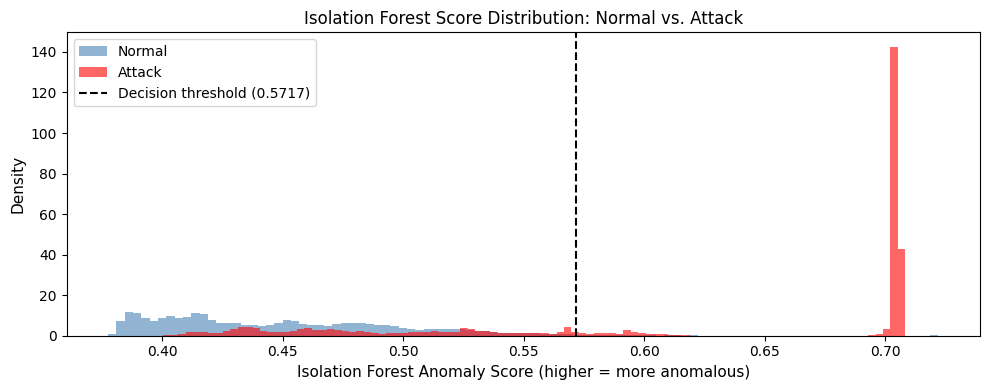

Normal scores — mean: 0.4502  std: 0.0513
Attack scores — mean: 0.6193  std: 0.1080


In [6]:
y_arr = y_true.values
normal_scores = iso_scores[y_arr == 0]
attack_scores = iso_scores[y_arr == 1]

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(normal_scores, bins=100, density=True, alpha=0.6, color='steelblue', label='Normal')
ax.hist(attack_scores, bins=100, density=True, alpha=0.6, color='red', label='Attack')

# Mark the decision threshold
threshold = np.percentile(iso_scores, (1 - 0.0379) * 100)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Decision threshold ({threshold:.4f})')

ax.set_xlabel('Isolation Forest Anomaly Score (higher = more anomalous)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Isolation Forest Score Distribution: Normal vs. Attack', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Normal scores — mean: {normal_scores.mean():.4f}  std: {normal_scores.std():.4f}')
print(f'Attack scores — mean: {attack_scores.mean():.4f}  std: {attack_scores.std():.4f}')

## Hyperparameter Sensitivity: Contamination Sweep

The `contamination` parameter sets the fraction of training data assumed to be anomalous, which determines the decision threshold. In production, you typically don't know the true anomaly rate.

The sweep below refits Isolation Forest for each contamination value and plots the resulting precision, recall, and F1. This shows:
1. How sensitive the model is to this key hyperparameter
2. The precision-recall tradeoff as the threshold is tightened/loosened
3. Where the optimal contamination estimate lies relative to the true rate (0.0379)

Sweeping contamination over 20 values...


Done.


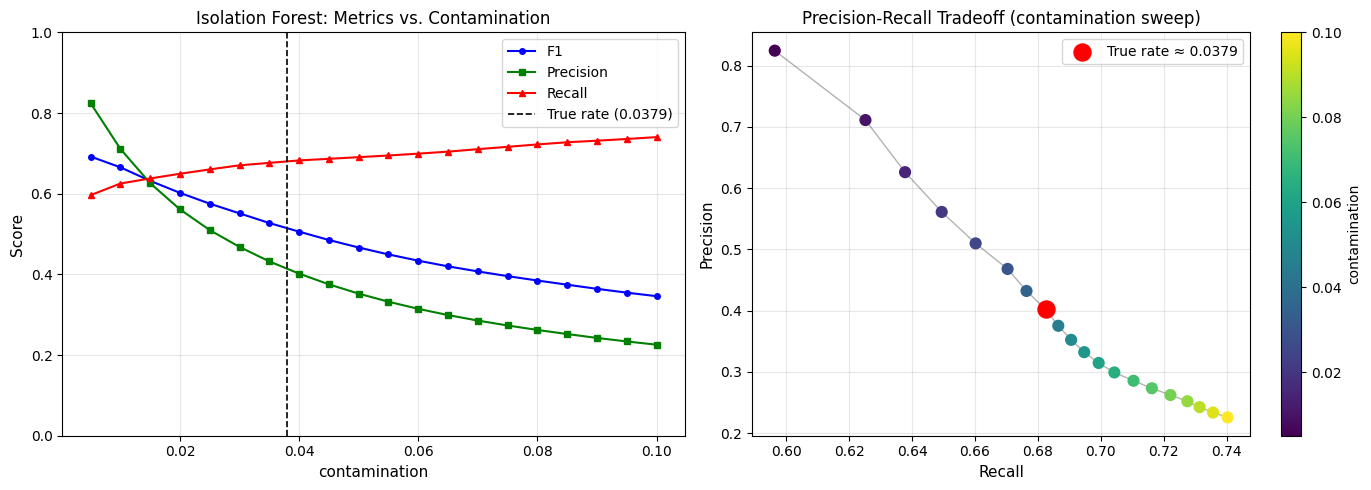

In [7]:
contamination_values = np.linspace(0.005, 0.10, 20)
sweep_results = []

print(f'Sweeping contamination over {len(contamination_values)} values...')
for c in contamination_values:
    clf = IsolationForest(n_estimators=100, contamination=c, random_state=42)
    clf.fit(X_train)
    pred = (clf.predict(X_test) == -1).astype(int)
    sweep_results.append({
        'contamination': c,
        'f1':        f1_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall':    recall_score(y_true, pred, zero_division=0),
    })

sweep_df = pd.DataFrame(sweep_results)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: P/R/F1 vs contamination
ax = axes[0]
ax.plot(sweep_df['contamination'], sweep_df['f1'],        'b-o', markersize=4, label='F1')
ax.plot(sweep_df['contamination'], sweep_df['precision'], 'g-s', markersize=4, label='Precision')
ax.plot(sweep_df['contamination'], sweep_df['recall'],    'r-^', markersize=4, label='Recall')
ax.axvline(0.0379, color='black', linestyle='--', linewidth=1.2, label='True rate (0.0379)')
ax.set_xlabel('contamination', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Isolation Forest: Metrics vs. Contamination', fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Right: Precision-Recall curve (contamination as implicit threshold)
ax2 = axes[1]
sc = ax2.scatter(sweep_df['recall'], sweep_df['precision'],
                 c=sweep_df['contamination'], cmap='viridis', s=60, zorder=3)
ax2.plot(sweep_df['recall'], sweep_df['precision'], 'k-', alpha=0.3, linewidth=1)
plt.colorbar(sc, ax=ax2, label='contamination')

# Mark the true-rate point
true_idx = (sweep_df['contamination'] - 0.0379).abs().idxmin()
ax2.scatter(sweep_df.loc[true_idx, 'recall'], sweep_df.loc[true_idx, 'precision'],
            color='red', s=150, zorder=5, label='True rate ≈ 0.0379')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Tradeoff (contamination sweep)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Time-Series Visualization

Two-panel plot showing ground truth attack labels alongside Isolation Forest predictions. Red shading marks actual attack windows on both panels.

Downsampled to 1-minute resolution (every 60th row) to keep the plot readable at ~24K points over 10 days.

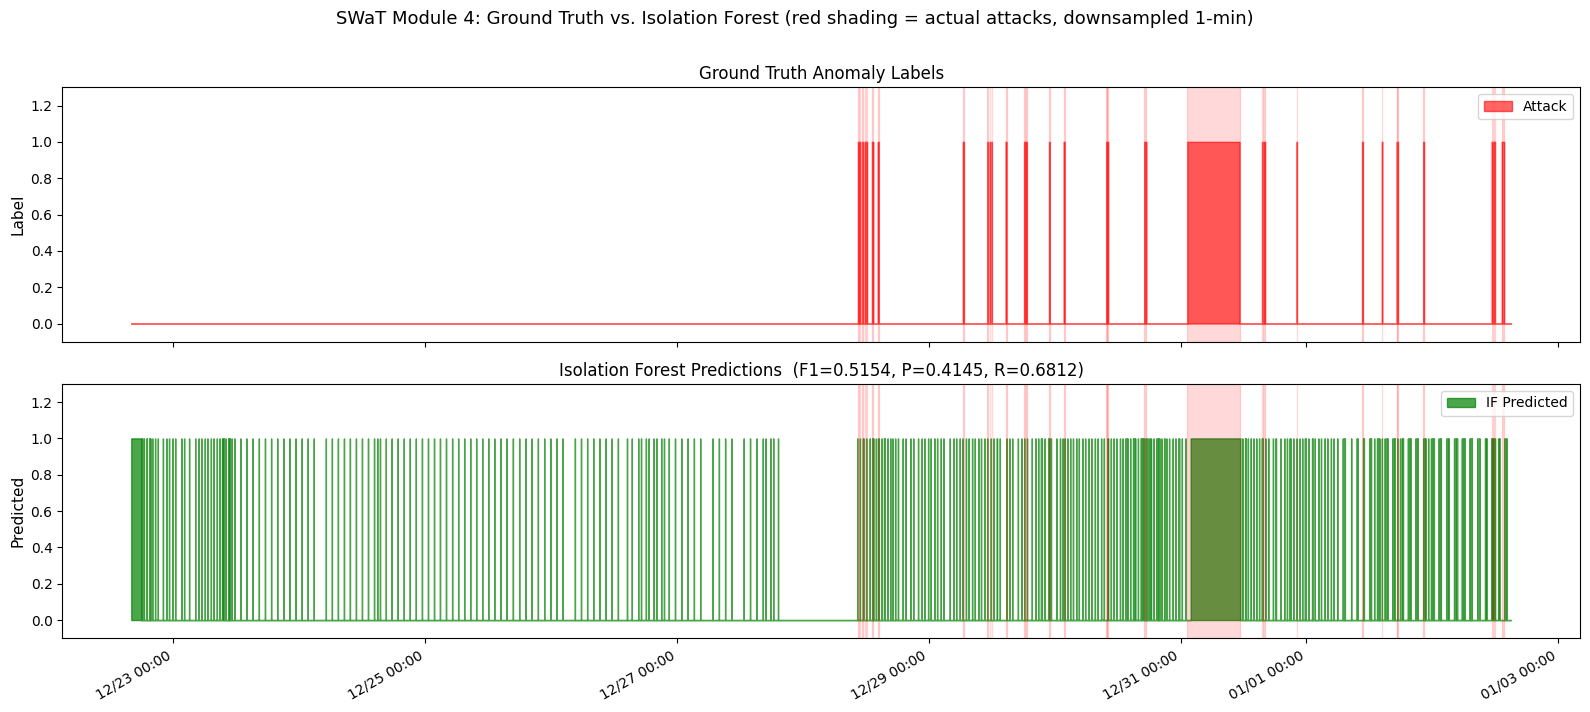

In [8]:
t = test_df.index
STEP = 60  # 1-minute resolution

t_plot      = t[::STEP]
y_plot      = y_true.values[::STEP]
if_plot     = iso_pred[::STEP]
attack_plot = y_plot.astype(bool)


def shade_attacks(ax, t, mask):
    """Shade contiguous attack regions in red."""
    in_attack = False
    start = None
    for i, (ts, flag) in enumerate(zip(t, mask)):
        if flag and not in_attack:
            start = ts
            in_attack = True
        elif not flag and in_attack:
            ax.axvspan(start, t[i - 1], color='red', alpha=0.15)
            in_attack = False
    if in_attack:
        ax.axvspan(start, t[-1], color='red', alpha=0.15)


fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Panel 1: Ground truth
axes[0].fill_between(t_plot, y_plot, step='mid', color='red', alpha=0.6, label='Attack')
shade_attacks(axes[0], t_plot, attack_plot)
axes[0].set_ylabel('Label', fontsize=11)
axes[0].set_title('Ground Truth Anomaly Labels', fontsize=12)
axes[0].set_ylim(-0.1, 1.3)
axes[0].legend(loc='upper right')

# Panel 2: Isolation Forest predictions
axes[1].fill_between(t_plot, if_plot, step='mid', color='green', alpha=0.7, label='IF Predicted')
shade_attacks(axes[1], t_plot, attack_plot)
axes[1].set_ylabel('Predicted', fontsize=11)
axes[1].set_title(
    f'Isolation Forest Predictions  '
    f'(F1={if_results["f1"]:.4f}, P={if_results["precision"]:.4f}, R={if_results["recall"]:.4f})',
    fontsize=12
)
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend(loc='upper right')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
fig.autofmt_xdate(rotation=30)

fig.suptitle(
    'SWaT Module 4: Ground Truth vs. Isolation Forest '
    '(red shading = actual attacks, downsampled 1-min)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## Analysis & Observations

### Results

| Method | Features | F1 | Precision | Recall |
|--------|----------|----|-----------|--------|
| Univariate Z-Score | 26 | 0.4249 | 0.2967 | 0.7480 |
| Mahalanobis Distance | 26 | **0.7240** | **0.7277** | **0.7202** |
| Isolation Forest | 51 | 0.5154 | 0.4145 | 0.6812 |

**Isolation Forest underperforms Mahalanobis substantially** — F1 0.5154 vs. 0.7240. Adding 25 binary actuator columns and removing the Gaussian assumption did not help; Mahalanobis wins decisively despite using half the features.

IF lands between z-score and Mahalanobis: better precision than z-score (0.4145 vs. 0.2967) but lower recall (0.6812 vs. 0.7480), with the net F1 only modestly above z-score (+0.09 F1 points). The confusion matrix tells the story:

```
IF:         [[1,334,527  52,571]    # 52K false alarms on normal rows
              [  17,411  37,210]]   # misses 31% of attack rows

Mahal:      [[1,372,380  14,718]    # only 14K false alarms
              [  15,281  39,340]]   # misses 28% of attack rows
```

Mahalanobis both raises fewer false alarms **and** catches more attacks.

### Why Mahalanobis wins on this dataset

SWaT attacks are designed to be stealthy by violating **sensor correlations** rather than absolute sensor levels. This is precisely the regime where Mahalanobis has a structural advantage:

- Mahalanobis explicitly encodes the full 26×26 covariance matrix — all 351 pairwise sensor relationships — learned from 1.38M rows of normal operation. Every prediction consults this dense global model of "how do all sensors normally move together."
- Isolation Forest selects features **randomly** at each split. In a 51-dimensional space, any single tree has low probability of simultaneously selecting the most informative correlated pair. The model implicitly learns correlation structure only in aggregate, across hundreds of trees, which is noisier than the explicit covariance encoding.

The score distribution confirms partial discriminability: normal mean score 0.4502 vs. attack mean 0.6193, but with substantial overlap — many attack rows score closer to normal than to the outlier tail.

### Did the binary actuators help?

No — or at least not enough to overcome the structural disadvantage above. This is somewhat counterintuitive given the hypothesis that actuator states encode operating modes inconsistent with attack-period sensor readings. Two explanations:

1. **Actuators add noise.** Pumps and valves toggle frequently during normal operation in response to tank level thresholds. This creates high variance in the actuator columns during normal operation, which dilutes their discriminative value in random tree splits.
2. **Attacks target sensors, not actuators.** SWaT's 36 attack scenarios predominantly spoof sensor readings (falsifying LIT levels, FIT flows) while leaving actuator states unchanged. The violations are in the sensor-to-sensor correlations, not sensor-to-actuator relationships.

### Contamination parameter mismatch

Setting `contamination=0.0379` (the known test attack rate) should produce ~3.79% predicted anomalies — but we observe **6.23%** flagged. The reason: contamination calibrates the threshold against the *training* distribution. The test set is a different distribution (a different week, with attack periods that shift the score distribution upward), so the same threshold flags more rows. This ~2.4 percentage-point overshoot contributed to the precision penalty. In production, this mismatch is unavoidable without a labeled validation set.

### Why OCSVM was omitted

One-Class SVM with an RBF kernel requires O(n²) memory to build the kernel matrix. At 1.38M training rows, the kernel matrix alone is ~7.6 TB. Even with subsampling, this method is infeasible at production scale without specialized infrastructure. This is not a limitation to work around:

> **At production scale (millions of rows), OCSVM is a non-starter. IF's sublinear training time makes it the practical default for large industrial datasets.**

### Practical takeaway

Isolation Forest is the right default when features include binary/categorical columns or when Gaussian assumptions are clearly violated. But on SWaT — a dataset where anomalies are defined by multivariate correlation violations among continuous sensors — Mahalanobis distance has a direct structural match to the problem that IF's randomized trees cannot replicate with the same precision.

| Consideration | Mahalanobis | Isolation Forest |
|---------------|-------------|------------------|
| SWaT F1 | **0.7240** | 0.5154 |
| Feature types | Continuous only | Any (continuous + binary) |
| Distribution assumption | Gaussian | None |
| Covariance structure | Explicit (global, dense) | Implicit (random, sparse per tree) |
| Threshold calibration | Chi-squared (principled) | Contamination rate (estimated, drifts) |
| Training scale | O(p²) in features | O(n · t · log n) in rows |
| Edge deployment | Trivial (mean + matrix) | Small model (~MB) |

The result here is a specific instance of a general principle: **model structure that matches the anomaly type wins.** Mahalanobis is purpose-built for covariance violations. IF is purpose-built for isolated outliers. SWaT's attacks are covariance violations — so Mahalanobis wins. On a dataset where anomalies manifest as isolated point outliers in nonlinear regions of feature space, the result would likely reverse.